In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyroomacoustics as pra
import torchaudio
import torchaudio.transforms
import random
import os
import tqdm

In [2]:
def random_room_dimensions():
    x = random.uniform(4, 10)
    y = random.uniform(4, 10)
    z = random.uniform(2.5, 5)
    return np.array([x, y, z])

def random_head_position(room_dim):
    rdx, rdy, _ = room_dim
    x = random.uniform(0.25*rdx, 0.75*rdx)
    y = random.uniform(0.25*rdy, 0.75*rdy)
    z = random.uniform(1, 1.75)
    return np.array([x, y, z])

def random_mouth_position(head_pos, head_ang):
    hpx, hpy, hpz = head_pos
    rdx = random.uniform(-0.01, 0.01)
    rdy = random.uniform(0.11, 0.15)
    rdz = random.uniform(0.02, 0.04)
    x = hpx + rdx*np.cos(head_ang) - rdy*np.sin(head_ang)
    y = hpy + rdx*np.sin(head_ang) + rdy*np.cos(head_ang)
    z = hpz - rdz
    return np.array([x, y, z])

def random_ears_position(head_pos, head_ang):
    hpx, hpy, hpz = head_pos
    rdx = random.uniform(0.08, 0.09)
    ear_center_l = np.array([hpx - rdx*np.cos(head_ang), hpy - rdx*np.sin(head_ang), hpz])
    ear_center_r = np.array([hpx + rdx*np.cos(head_ang), hpy + rdx*np.sin(head_ang), hpz])
    return np.array([ear_center_l, ear_center_r])

def define_mics_position(ears_pos):
    ear_center_l, ear_center_r = ears_pos
    lex, ley, lez = ear_center_l
    rex, rey, rez = ear_center_r
    mic_l_1 = np.array([lex, ley, lez - 0.01])
    mic_l_2 = np.array([lex, ley, lez + 0.01])    
    mic_r_1 = np.array([rex, rey, rez - 0.01])
    mic_r_2 = np.array([rex, rey, rez + 0.01])
    return np.array([mic_l_1, mic_l_2, mic_r_1, mic_r_2])

def random_distractor_position(room_dim, head_pos):
    rdx, rdy, _ = room_dim
    hpx, hpy, _ = head_pos
    x = random.uniform(0, hpx-0.75) if random.randint(0, 1) else random.uniform(hpx+0.75, rdx)
    y = random.uniform(0, hpy-0.75) if random.randint(0, 1) else random.uniform(hpy+0.75, rdy)
    z = random.uniform(1, 1.75)
    return np.array([x, y, z])

def room_plot_2D(room):
    room = pra.ShoeBox(room_dim[0:2], fs=16000)
    room.add_source(mouth_pos[0:2])
    room.add_microphone_array(mics_pos.T[0:2])
    room.add_source(distractor_pos[0:2])
    room.plot()    

In [3]:
room_dim = random_room_dimensions()
print(room_dim)

[7.45740838 4.58626492 3.65543636]


In [4]:
head_pos = random_head_position(room_dim)
print(head_pos)

[2.33858966 2.17479359 1.14823014]


In [5]:
head_ang = random.uniform(0, 2*np.pi)
print(head_ang)

4.458373189152991


In [6]:
ears_pos = random_ears_position(head_pos, head_ang)
print(ears_pos)

[[2.35875599 2.25246876 1.14823014]
 [2.31842332 2.09711842 1.14823014]]


In [7]:
mics_pos = define_mics_position(ears_pos)
print(mics_pos)

[[2.35875599 2.25246876 1.13823014]
 [2.35875599 2.25246876 1.15823014]
 [2.31842332 2.09711842 1.13823014]
 [2.31842332 2.09711842 1.15823014]]


In [8]:
mouth_pos = random_mouth_position(head_pos,  head_ang)
print(mouth_pos)

[2.46326814 2.15164039 1.1133271 ]


In [9]:
distractor_pos = random_distractor_position(room_dim, head_pos)
print(distractor_pos)

[0.57191636 0.28814143 1.27718402]


In [10]:
# x = np.zeros(1000)

# for i in range(1000):
#     room_dim = random_room_dimensions()
#     head_position = random_head_position(room_dim)
#     distractor_position = random_distractor_position(room_dim, head_position)
#     distance_between_head_and_distractor = np.linalg.norm(head_position - distractor_position)
#     x[i] = distance_between_head_and_distractor

# x.mean()

In [11]:
# def random_snr():
#     return random.uniform(-5, 5)

# def random_rt60():
#     return random.uniform(0, 1)

In [12]:
# rt60 = random_rt60()
# e_absorption, max_order = pra.inverse_sabine(rt60, room_dim)

In [13]:
room = pra.ShoeBox(room_dim, fs=16000)
room.add_source(mouth_pos)
room.add_microphone_array(mics_pos.T)
room.add_source(distractor_pos)

(<Figure size 640x480 with 1 Axes>, <Axes3D: >)

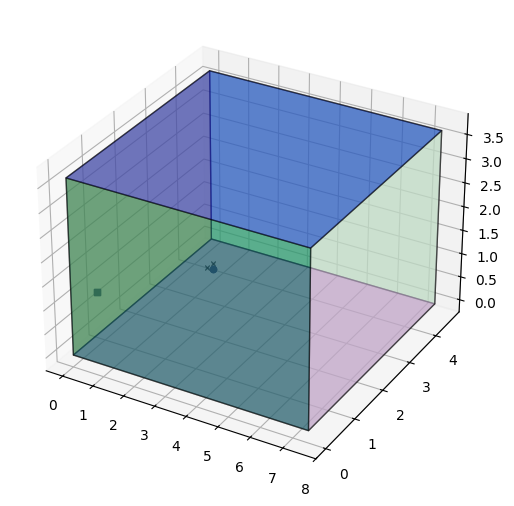

In [14]:
room.plot()

(<Figure size 640x480 with 1 Axes>, <Axes: >)

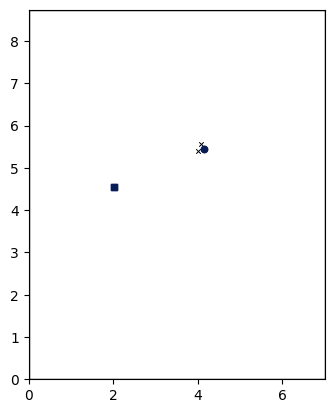

In [538]:
room = pra.ShoeBox(room_dim[0:2], fs=16000)
room.add_source(mouth_pos[0:2])
room.add_microphone_array(mics_pos.T[0:2])
room.add_source(distractor_pos[0:2])
room.plot()

In [539]:
distractor_pos

array([2.03078054, 4.54305408, 1.15142141])

In [540]:
room_dim

array([7.00352455, 8.74124276, 3.50788366])

In [541]:
head_ang

4.342862235666053